In [ ]:
import yfinance as yf
data = yf.download("AAPL", period="4y", interval="1d")


/tmp/ipython-input-4274864145.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", period="4y", interval="1d")
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Print the first 10 entries
print(data.head(10))

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-08-12  145.759476  145.916115  142.773601  143.116248   72282600
2021-08-13  145.965057  146.297905  145.152507  145.837786   59375000
2021-08-16  147.942551  148.011086  143.390327  145.416796  103296000
2021-08-17  147.032135  148.490797  145.955257  147.071287   92229700
2021-08-18  143.282669  147.550997  143.077078  146.650343   86326000
2021-08-19  143.615494  144.888163  141.461754  141.980609   86960300
2021-08-20  145.074173  145.377653  143.693816  144.339942   60549600
2021-08-23  146.562225  147.032129  144.780485  145.191653   60131800
2021-08-24  146.474106  147.688039  146.013987  146.307682   48606400
2021-08-25  145.240601  147.159396  144.692377  146.660110   58991300


/tmp/ipython-input-1619197745.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, period="4y", interval="1d")
[*********************100%***********************]  1 of 1 completed


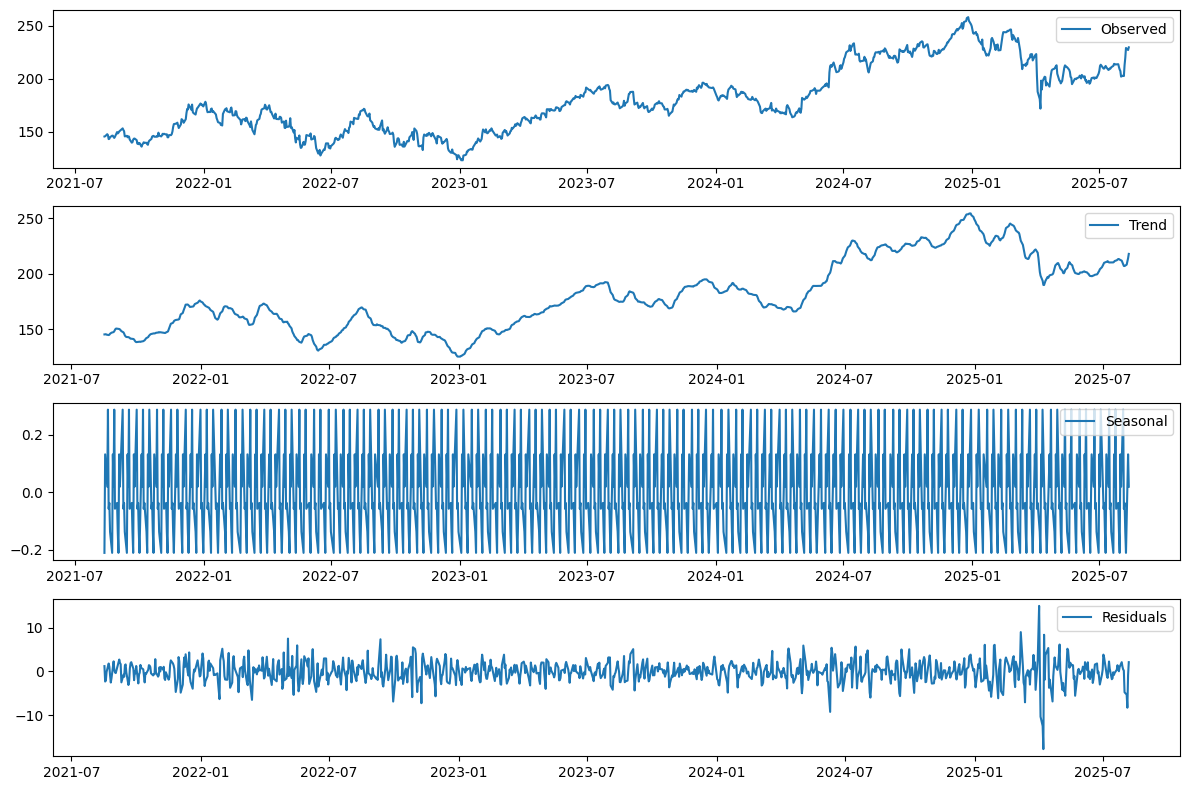

Date with Minimum Seasonal Value: 2021-08-12
Date with Maximum Seasonal Value: 2021-08-17


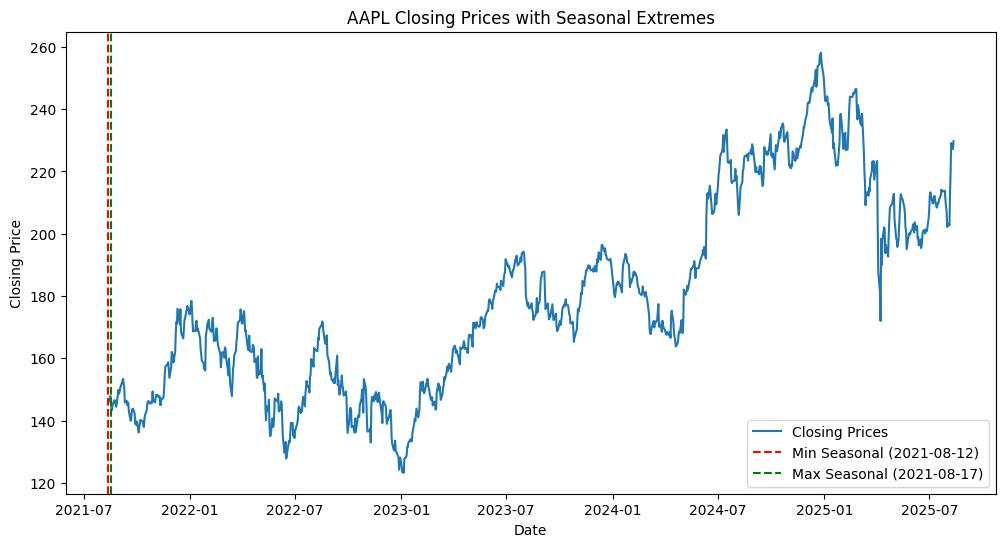

In [ ]:
# Install necessary packages
!pip install yfinance statsmodels matplotlib pandas

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Step 1: Download stock data (Example: Apple - 'AAPL')
stock_symbol = "AAPL"
data = yf.download(stock_symbol, period="4y", interval="1d")

# Step 2: Keep only the closing prices
closing_prices_df = data[['Close']].dropna()

# Step 3: Seasonal decomposition
# Assuming weekly seasonality (7 trading days ≈ 1 week)
decomposition = seasonal_decompose(closing_prices_df, model='additive', period=7)

# Step 4: Plot the decomposition
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='best')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='best')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal')
plt.legend(loc='best')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

# Step 5: Find dates with minimum & maximum seasonal values
seasonal_component = decomposition.seasonal
min_seasonal_date = seasonal_component.idxmin()
max_seasonal_date = seasonal_component.idxmax()

print(f"Date with Minimum Seasonal Value: {min_seasonal_date.date()}")
print(f"Date with Maximum Seasonal Value: {max_seasonal_date.date()}")

# Step 6: Visualization with predicted points
plt.figure(figsize=(12, 6))
plt.plot(closing_prices_df, label='Closing Prices')
plt.axvline(min_seasonal_date, color='r', linestyle='--',
            label=f'Min Seasonal ({min_seasonal_date.date()})')
plt.axvline(max_seasonal_date, color='g', linestyle='--',
            label=f'Max Seasonal ({max_seasonal_date.date()})')
plt.title(f'{stock_symbol} Closing Prices with Seasonal Extremes')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()
